# Fundamentos de Series de Tiempo

En este notebook exploramos los conceptos fundamentales de series de tiempo usando un dataset real: el clásico **AirPassengers** (número mensual de pasajeros aéreos internacionales, 1949-1960).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

## 1. Carga y visualización de la serie

In [14]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df["Month"] = pd.to_datetime(df["Month"])
df = df.set_index("Month")
df = df.asfreq("MS")  # frecuencia mensual, inicio de mes

print(df.shape)
df.head()

(144, 1)


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


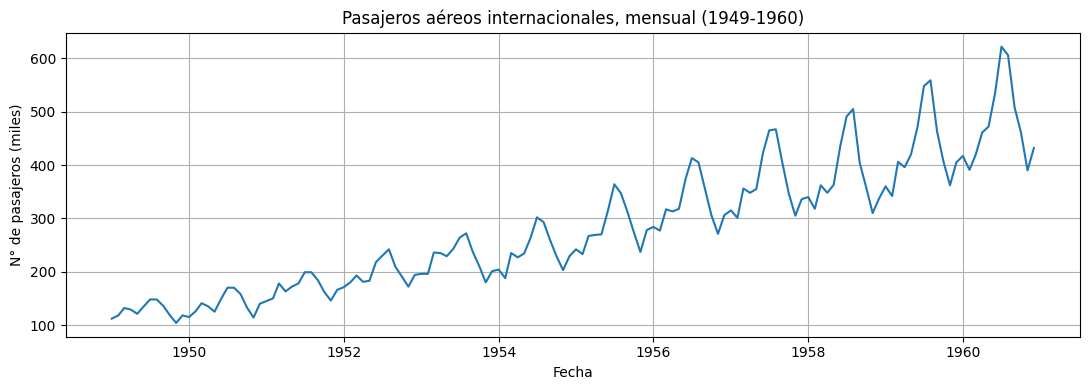

In [15]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Passengers"], color="tab:blue")
ax.set_title("Pasajeros aéreos internacionales, mensual (1949-1960)")
ax.set_xlabel("Fecha")
ax.set_ylabel("N° de pasajeros (miles)")
plt.tight_layout()
plt.show()

¿Qué componentes se ven a simple vista?
- Tendencia: claramente creciente
- Estacionalidad: el patrón se repite cada 12 meses (viajes de verano)
- Notar que la *amplitud* de la estacionalidad crece junto con la tendencia

## 2. ¿Por qué no podemos hacer un split aleatorio?

Antes de seguir, ilustramos por qué el train/test split debe ser **secuencial** y no aleatorio en series de tiempo.

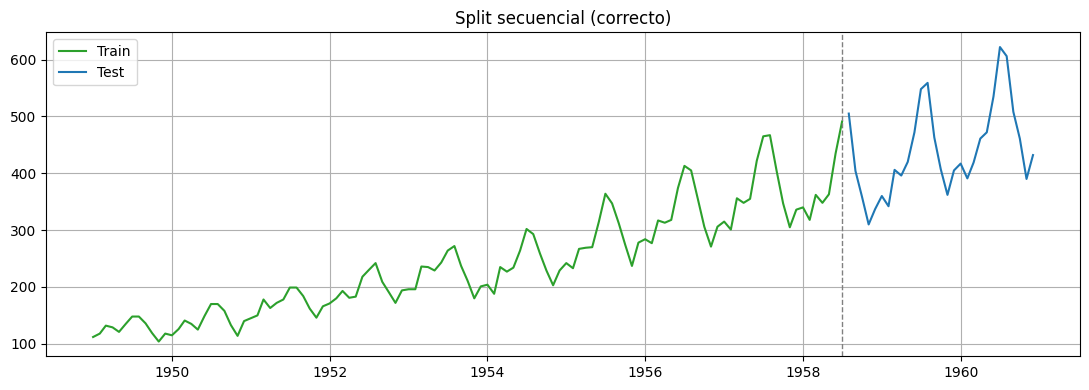

Train: 1949-01-01 a 1958-07-01 (115 obs.)
Test:  1958-08-01 a 1960-12-01 (29 obs.)


In [16]:
n = len(df)
split_point = int(n * 0.8)

train = df.iloc[:split_point]
test = df.iloc[split_point:]

fig, ax = plt.subplots()
ax.plot(train.index, train["Passengers"], label="Train", color="tab:green")
ax.plot(test.index, test["Passengers"], label="Test", color="tab:blue")
ax.axvline(train.index[-1], color="gray", linestyle="--", linewidth=1)
ax.set_title("Split secuencial (correcto)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train: {train.index.min().date()} a {train.index.max().date()} ({len(train)} obs.)")
print(f"Test:  {test.index.min().date()} a {test.index.max().date()} ({len(test)} obs.)")

## 3. Descomposición de la serie

Separamos la serie en tendencia, estacionalidad y residuo con `seasonal_decompose`.

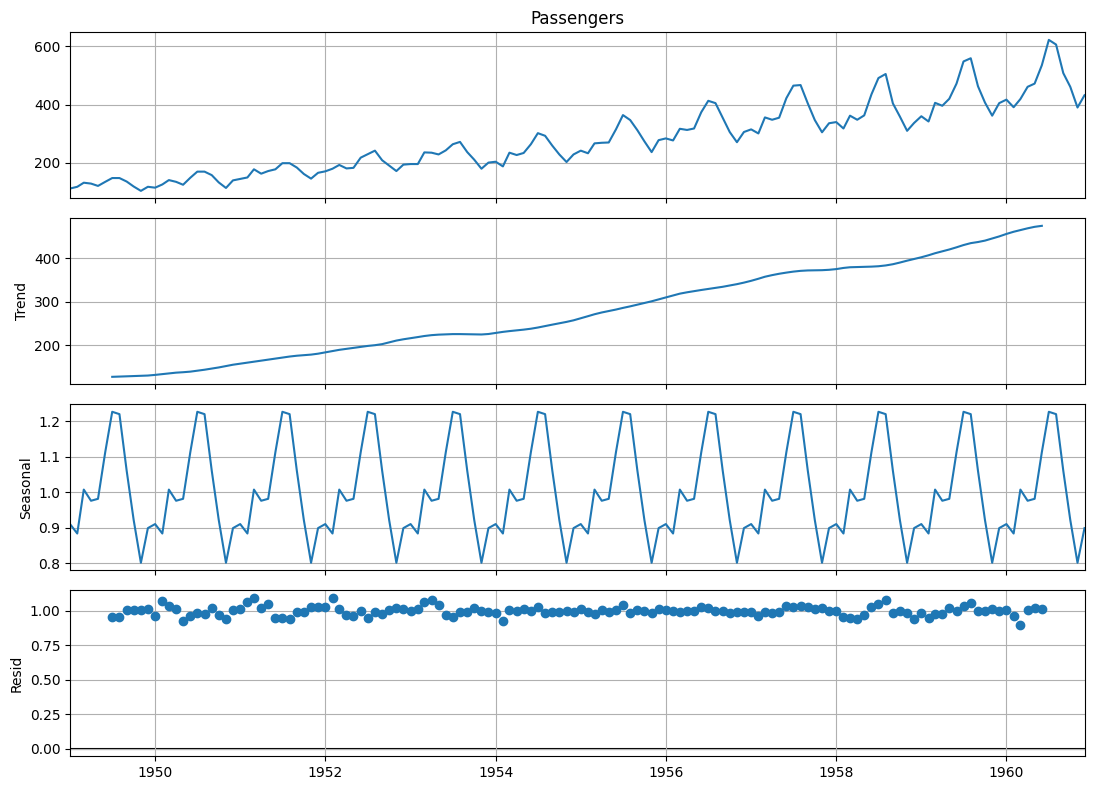

In [17]:
resultado = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)

fig = resultado.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

In [18]:
# Los componentes quedan disponibles por separado
print("Tendencia (primeras filas, con NaN por la media móvil centrada):")
print(resultado.trend.head(8))
print()
print("Estacionalidad (primeros 12 valores, un ciclo completo):")
print(resultado.seasonal.head(12))

Tendencia (primeras filas, con NaN por la media móvil centrada):
Month
1949-01-01           NaN
1949-02-01           NaN
1949-03-01           NaN
1949-04-01           NaN
1949-05-01           NaN
1949-06-01           NaN
1949-07-01    126.791667
1949-08-01    127.250000
Freq: MS, Name: trend, dtype: float64

Estacionalidad (primeros 12 valores, un ciclo completo):
Month
1949-01-01    0.910230
1949-02-01    0.883625
1949-03-01    1.007366
1949-04-01    0.975906
1949-05-01    0.981378
1949-06-01    1.112776
1949-07-01    1.226556
1949-08-01    1.219911
1949-09-01    1.060492
1949-10-01    0.921757
1949-11-01    0.801178
1949-12-01    0.898824
Freq: MS, Name: seasonal, dtype: float64


- Los primeros y últimos 6 valores de `trend` son `NaN` (media móvil centrada de ventana 12)
- El patrón estacional (`seasonal`) se repite idéntico cada 12 observaciones

## 4. Estacionariedad y el test ADF

Una serie estacionaria tiene media y varianza constantes en el tiempo. La mayoría de los modelos clásicos lo requieren.

El test de Dickey-Fuller Aumentado (ADF) contrasta:
- $H_0$: la serie tiene raíz unitaria (no es estacionaria)
- $H_1$: la serie es estacionaria

Si el p-value es menor a 0.05, rechazamos $H_0$ y concluimos que la serie es estacionaria.

In [ ]:
def test_adf(serie, nombre="serie"):
    resultado = adfuller(serie.dropna())
    print(f"--- ADF test: {nombre} ---")
    print(f"Estadístico ADF: {resultado[0]:.4f}")
    print(f"p-value:         {resultado[1]:.4f}")
    for clave, valor in resultado[4].items():
        print(f"Valor crítico ({clave}): {valor:.4f}")
    conclusion = "ESTACIONARIA" if resultado[1] < 0.05 else "NO estacionaria"
    print(f"Conclusión: {conclusion}\n")

test_adf(df["Passengers"], "Serie original")

--- ADF test: Serie original ---
Estadístico ADF: 0.8154
p-value:         0.9919
Valor crítico (1%): -3.4817
Valor crítico (5%): -2.8840
Valor crítico (10%): -2.5788
Conclusión: NO estacionaria



/tmp/ipykernel_119/599868019.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(serie.dropna())


Como era de esperar, la serie original **no es estacionaria** (tiene tendencia y estacionalidad claras). Apliquemos transformaciones para intentar estabilizarla.

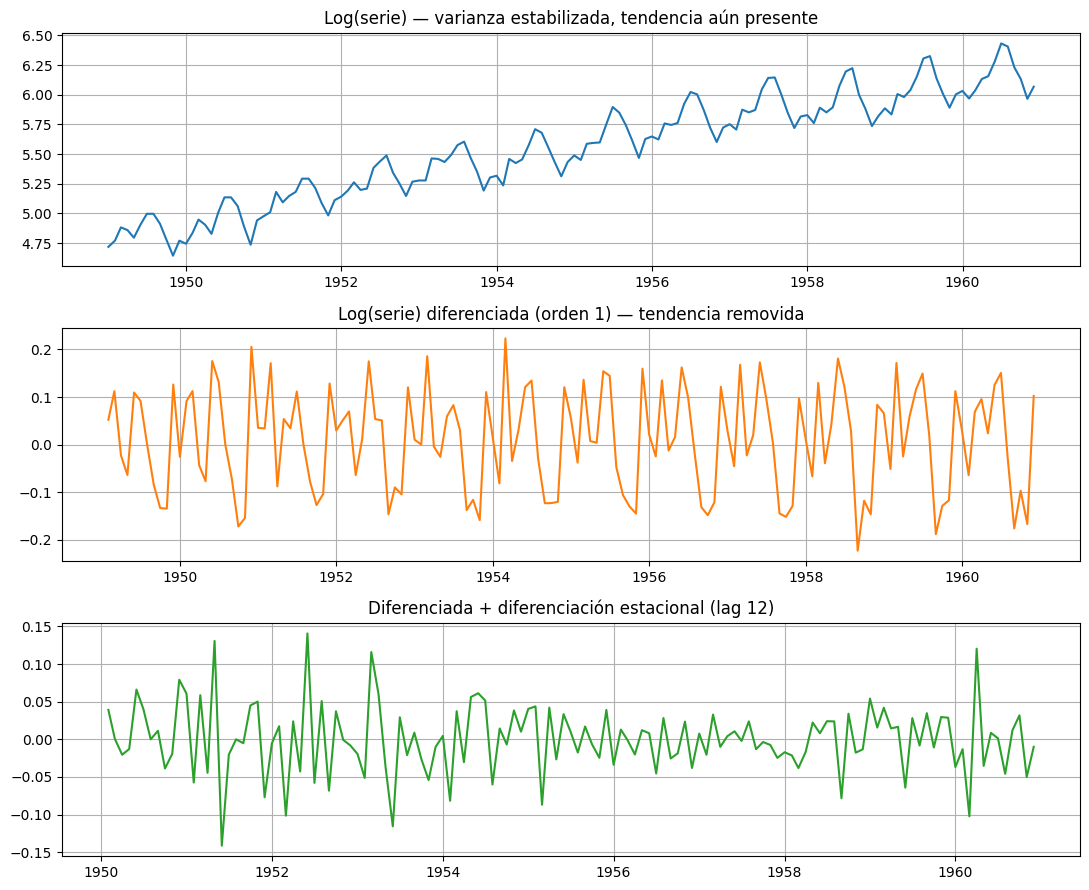

--- ADF test: Serie log + diff(1) + diff(12) ---
Estadístico ADF: -4.4433
p-value:         0.0002
Valor crítico (1%): -3.4870
Valor crítico (5%): -2.8864
Valor crítico (10%): -2.5800
Conclusión: ESTACIONARIA



/tmp/ipykernel_119/599868019.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(serie.dropna())


In [ ]:
# Transformación logarítmica (para estabilizar la varianza que crece con la tendencia)
log_serie = np.log(df["Passengers"])

# Diferenciación de orden 1 (para remover la tendencia)
diff_serie = log_serie.diff().dropna()

# Diferenciación estacional adicional (para remover la estacionalidad anual)
diff_estacional = diff_serie.diff(12).dropna()

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)
axes[0].plot(log_serie, color="tab:blue")
axes[0].set_title("Log(serie) — varianza estabilizada, tendencia aún presente")
axes[1].plot(diff_serie, color="tab:orange")
axes[1].set_title("Log(serie) diferenciada (orden 1) — tendencia removida")
axes[2].plot(diff_estacional, color="tab:green")
axes[2].set_title("Diferenciada + diferenciación estacional (lag 12)")
plt.tight_layout()
plt.show()

test_adf(diff_estacional, "Serie log + diff(1) + diff(12)")

## 5. Autocorrelación: ACF y PACF

- **ACF (autocorrelation function):** correlación de la serie consigo misma en distintos rezagos (lags)
- **PACF (partial autocorrelation function):** correlación en el lag $k$, removiendo el efecto de los lags intermedios

Se grafican sobre la serie ya estacionaria (la diferenciada), no sobre la original.

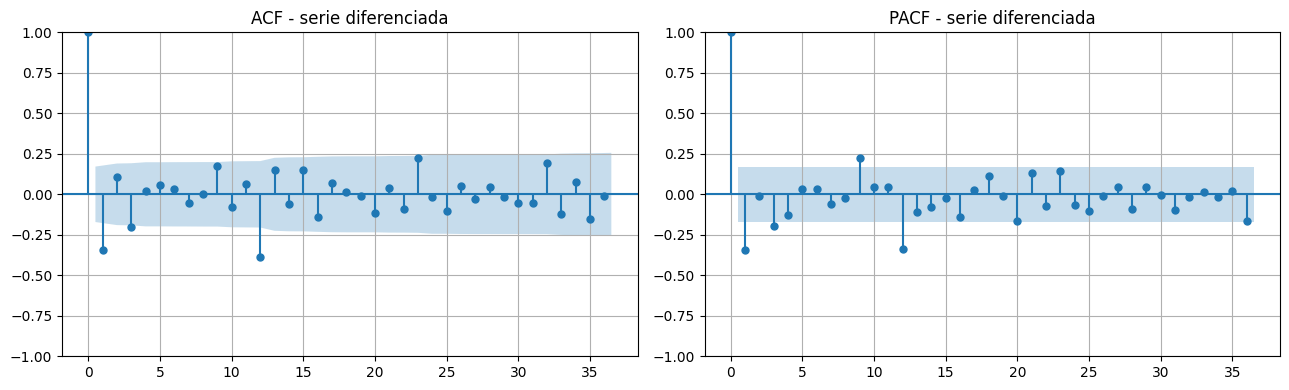

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(diff_estacional, lags=36, ax=axes[0])
axes[0].set_title("ACF - serie diferenciada")
plot_pacf(diff_estacional, lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF - serie diferenciada")
plt.tight_layout()
plt.show()

## 6. Preprocesamiento práctico

Herramientas que se usan tanto para análisis exploratorio como para preparar features de cara a modelos de Machine Learning.

In [ ]:
# Resampling: de mensual a anual (promedio)
anual = df["Passengers"].resample("YE").mean()
print("Promedio anual de pasajeros:")
print(anual.head())

Promedio anual de pasajeros:
Month
1949-12-31    126.666667
1950-12-31    139.666667
1951-12-31    170.166667
1952-12-31    197.000000
1953-12-31    225.000000
Freq: YE-DEC, Name: Passengers, dtype: float64


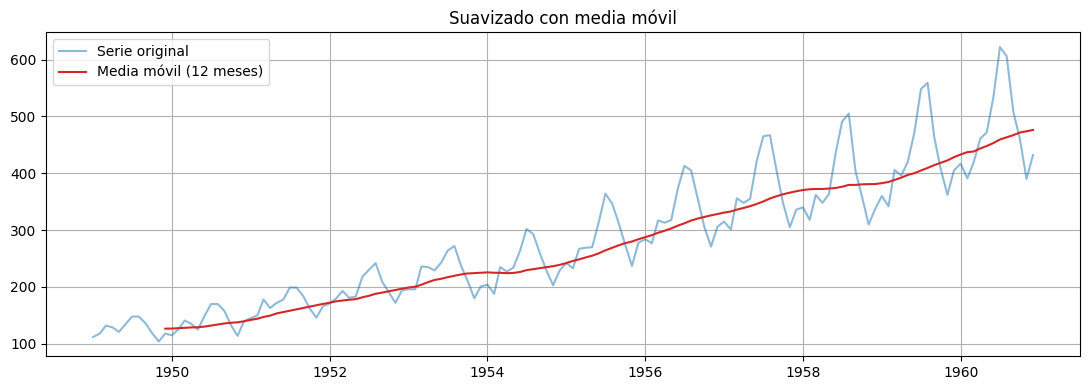

In [ ]:
# Suavizado con media móvil
df["media_movil_12"] = df["Passengers"].rolling(window=12).mean()

fig, ax = plt.subplots()
ax.plot(df.index, df["Passengers"], label="Serie original", alpha=0.5)
ax.plot(df.index, df["media_movil_12"], label="Media móvil (12 meses)", color="tab:red")
ax.set_title("Suavizado con media móvil")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Feature engineering temporal: lags, rolling stats y variables de calendario
features = pd.DataFrame(index=df.index)
features["y"] = df["Passengers"]

# Lags
for lag in [1, 2, 3, 12]:
    features[f"lag_{lag}"] = features["y"].shift(lag)

# Rolling stats (usando solo información pasada: shift(1) antes de rolling)
features["rolling_mean_3"] = features["y"].shift(1).rolling(window=3).mean()
features["rolling_std_3"] = features["y"].shift(1).rolling(window=3).std()

# Variables de calendario
features["mes"] = features.index.month
features["trimestre"] = features.index.quarter

features.dropna().head(10)

,y,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3,mes,trimestre
Month,,,,,,,,,
1950-01-01,115,118.0,104.0,119.0,112.0,113.666667,8.386497,1,1
1950-02-01,126,115.0,118.0,104.0,118.0,112.333333,7.371115,2,1
1950-03-01,141,126.0,115.0,118.0,132.0,119.666667,5.686241,3,1
1950-04-01,135,141.0,126.0,115.0,129.0,127.333333,13.051181,4,2
1950-05-01,125,135.0,141.0,126.0,121.0,134.000000,7.549834,5,2
1950-06-01,149,125.0,135.0,141.0,135.0,133.666667,8.082904,6,2
1950-07-01,170,149.0,125.0,135.0,148.0,136.333333,12.055428,7,3
1950-08-01,170,170.0,149.0,125.0,148.0,148.000000,22.516660,8,3
1950-09-01,158,170.0,170.0,149.0,136.0,163.000000,12.124356,9,3
